In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats
from sparrow import Protein

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
construct_stats = pd.read_csv('constructs_df.csv', index_col=0)

construct_stats['construct'] = construct_stats['construct'].astype(str)

In [3]:
# Function to calculate sequence features and predictions using sparrow
def calculate_sparrow_features(seqs_df):
    features = []
    for idx, row in seqs_df.iterrows():
        seq = row['sequence']
        construct = row['construct']
        protein = Protein(seq)
        
        # Calculate features
        f_positive = protein.fraction_positive
        f_negative = protein.fraction_negative
        aro = protein.fraction_aromatic
        ali = protein.fraction_aliphatic
        polar = protein.fraction_polar
        proline = protein.fraction_proline
        scd = protein.SCD                    # Uppercase SCD
        shd = protein.SHD                    # Uppercase SHD
        ncpr = protein.NCPR                  # Uppercase NCPR
        fcr = protein.FCR                    # Uppercase FCR
        hydrophobicity = protein.hydrophobicity
        kappa = protein.kappa
        
        # Predictions
        rg = protein.predictor.radius_of_gyration()
        re = protein.predictor.end_to_end_distance()
        mean_disorder = np.mean(protein.predictor.disorder())
        asphericity = protein.predictor.asphericity()
        scaling_exp = protein.predictor.scaling_exponent()
        prefactor = protein.predictor.prefactor()
        coil = protein.predictor.dssp_coil()
        extended = protein.predictor.dssp_extended()
        helicity = protein.predictor.dssp_helicity()
        
        features.append({
            'construct': construct,
            'f_positive': f_positive,
            'f_negative': f_negative,
            'aro': aro,
            'ali': ali,
            'polar': polar,
            'proline': proline,
            'scd': scd,
            'shd': shd,
            'NCPR': ncpr,
            'FCR': fcr,
            'hydrophobicity': hydrophobicity,
            'kappa': kappa,
            'rg': rg,
            're': re,
            'mean_disorder': mean_disorder,
            'asphericity': asphericity,
            'scaling_exponent': scaling_exp,
            'prefactor': prefactor,
            'coil': coil,
            'extended': extended,
            'helicity': helicity
        })
    return pd.DataFrame(features)

# Calculate features and predictions, then merge with construct_stats
sparrow_features = calculate_sparrow_features(construct_stats)
construct_stats = construct_stats.merge(sparrow_features, on='construct', how='left')

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


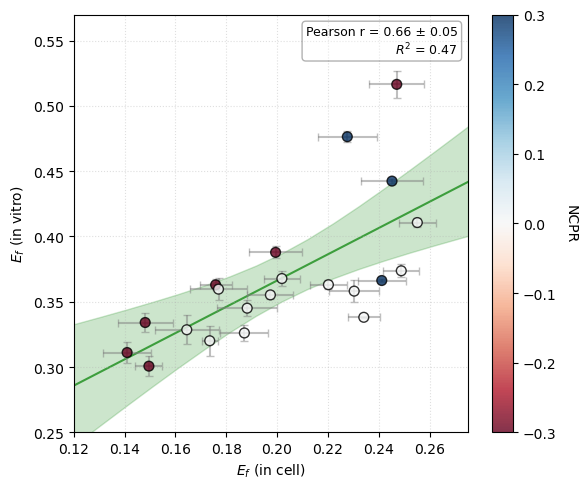

In [ ]:
# plot Ef_cell vs Ef_invitro with error bars - with color parameter
mask = construct_stats[['Ef_cell', 'Ef_cell_std', 'Ef_invitro', 'Ef_invitro_std']].notnull().all(axis=1)
plot_df = construct_stats.loc[mask].copy()

x = plot_df['Ef_cell']
y = plot_df['Ef_invitro']
xerr = plot_df['Ef_cell_std']
yerr = plot_df['Ef_invitro_std']

# Set color parameter - change this to any column name
color_by = 'NCPR'  # Options: 'NCPR', 'kappa', 'hydrophobicity', etc., or None for single color
colors = plot_df[color_by] if color_by else 'blue'

# Monte Carlo sampling for Pearson correlation
n_iterations = 1000
pearson_values = []

for _ in range(n_iterations):
    sampled_x = np.random.normal(plot_df['Ef_cell'], plot_df['Ef_cell_std'])
    sampled_y = np.random.normal(plot_df['Ef_invitro'], plot_df['Ef_invitro_std'])
    pearson_r_sample, _ = sp_stats.pearsonr(sampled_x, sampled_y)
    pearson_values.append(pearson_r_sample)

pearson_r_mean = np.mean(pearson_values)
pearson_r_std = np.std(pearson_values)

fig, ax = plt.subplots(figsize=(6, 5))

# Linear regression
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(x, y)

# Calculate 95% confidence interval for the regression line
n = len(x)
dof = n - 2  # degrees of freedom
t_val = sp_stats.t.ppf(0.975, dof)  # 95% confidence interval

x_mean = np.mean(x)
sxx = np.sum((x - x_mean)**2)

# Get x limits and create line
x_limits = ax.get_xlim()
line_x = np.linspace(x_limits[0], x_limits[1], 100)
line_y = slope * line_x + intercept

# Calculate prediction error
predict_y = slope * x + intercept
residuals = y - predict_y
s_resid = np.sqrt(np.sum(residuals**2) / dof)

# Standard error of the fit
se_line = s_resid * np.sqrt(1/n + (line_x - x_mean)**2 / sxx)
margin = t_val * se_line

# Plot shaded confidence interval
ax.fill_between(line_x, line_y - margin, line_y + margin,
                color='green', alpha=0.2, zorder=0)

# Plot regression line
ax.plot(line_x, line_y, color='green', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)

# Plot points
scatter = ax.scatter(x, y, c=colors, cmap='RdBu' if color_by else None,
                     edgecolors='black', linewidths=1, alpha=0.8, s=50, zorder=2)

# Add error bars
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
            ecolor='grey', capsize=3, alpha=0.5, zorder=1)

# Add colorbar if coloring by a parameter
if color_by:
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(color_by, rotation=270, labelpad=15)

ax.set_xlabel('$E_{f}$ (in cell)')
ax.set_ylabel('$E_{f}$ (in vitro)')
ax.grid(True, linestyle=':', alpha=0.4)

ax.text(0.975, 0.975, f'Pearson r = {pearson_r_mean:.2f} ± {pearson_r_std:.2f}\n$R^2$ = {r_value**2:.2f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.3))

plt.xlim(0.12, .275)
plt.ylim(.25, .57)
plt.tight_layout()
plt.savefig('Figure_graphs/Fig2/Ef_incell-vs-invitro.svg')

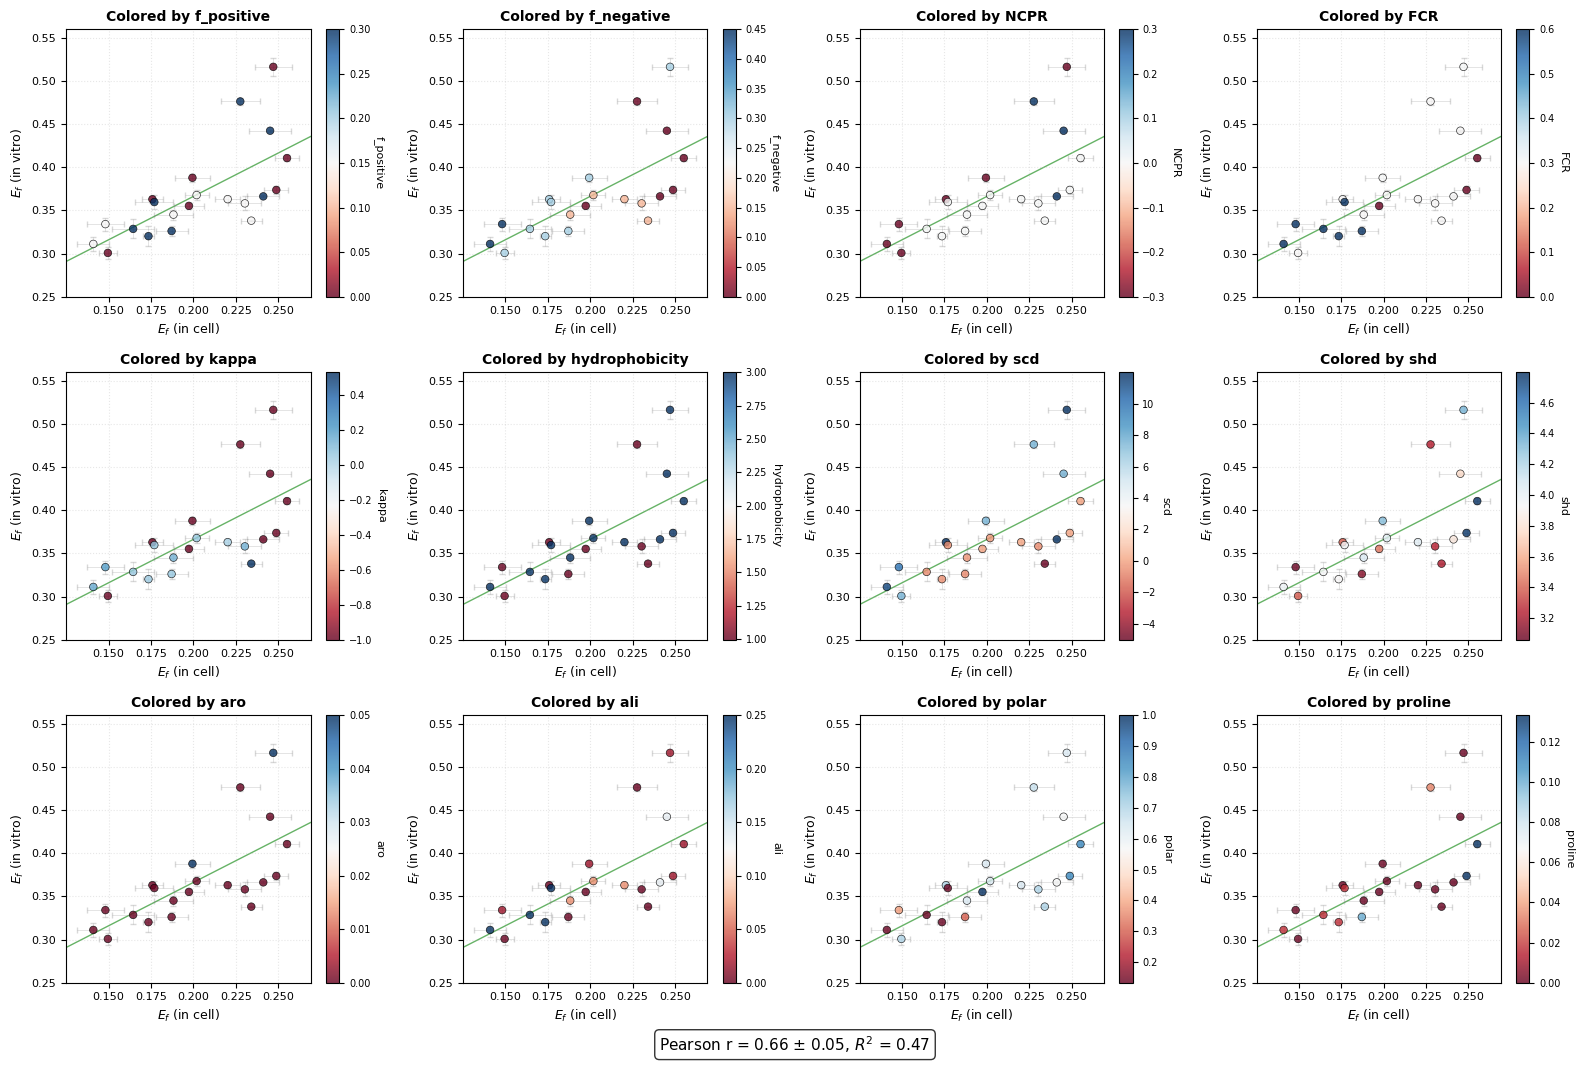

In [5]:
# plot Ef_cell vs Ef_invitro with error bars - subplots colored by different parameters
mask = construct_stats[['Ef_cell', 'Ef_cell_std', 'Ef_invitro', 'Ef_invitro_std']].notnull().all(axis=1)
plot_df = construct_stats.loc[mask].copy()

x = plot_df['Ef_cell']
y = plot_df['Ef_invitro']
xerr = plot_df['Ef_cell_std']
yerr = plot_df['Ef_invitro_std']

# Monte Carlo sampling for Pearson correlation (once for all subplots)
n_iterations = 1000
pearson_values = []

for _ in range(n_iterations):
    sampled_x = np.random.normal(plot_df['Ef_cell'], plot_df['Ef_cell_std'])
    sampled_y = np.random.normal(plot_df['Ef_invitro'], plot_df['Ef_invitro_std'])
    pearson_r_sample, _ = sp_stats.pearsonr(sampled_x, sampled_y)
    pearson_values.append(pearson_r_sample)

pearson_r_mean = np.mean(pearson_values)
pearson_r_std = np.std(pearson_values)

# Linear regression (once for all subplots)
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(x, y)
# Parameters to color by
color_params = ['f_positive', 'f_negative', 'NCPR', 'FCR', 'kappa', 'hydrophobicity', 
                'scd', 'shd', 'aro', 'ali', 'polar', 'proline']

# Create subplots - 3 rows x 4 columns
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, color_by in enumerate(color_params):
    ax = axes[idx]
    
    # Get colors for this parameter
    colors = plot_df[color_by]
    
    # Plot points with RdBu_r colormap (red-white-blue)
    scatter = ax.scatter(x, y, c=colors, cmap='RdBu',
                         edgecolors='black', linewidths=0.5, alpha=0.8, s=30, zorder=2,
                         vmin=colors.min(), vmax=colors.max())
    
    # Add error bars
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                ecolor='grey', capsize=2, alpha=0.3, zorder=1, linewidth=0.5)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(color_by, rotation=270, labelpad=10, fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    
    # Get x-axis limits and plot regression line
    x_limits = ax.get_xlim()
    line_x = np.array(x_limits)
    line_y = slope * line_x + intercept
    
    ax.plot(line_x, line_y, color='green', linestyle='-', linewidth=1, alpha=0.6, zorder=0)
    
    ax.set_xlabel('$E_{f}$ (in cell)', fontsize=9)
    ax.set_ylabel('$E_{f}$ (in vitro)', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.tick_params(labelsize=8)
    
    # Add title with parameter name
    ax.set_title(f'Colored by {color_by}', fontsize=10, fontweight='bold')
    
    ax.set_xlim(x_limits[0], x_limits[1])
    ax.set_ylim(.25, .56)

# Add overall statistics text to the figure
fig.text(0.5, 0.02, f'Pearson r = {pearson_r_mean:.2f} ± {pearson_r_std:.2f}, $R^2$ = {r_value**2:.2f}', 
         ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout(rect=[0, 0.03, 1, .9])
#plt.savefig('Figure_graphs/Fig2/Ef_cell_vs_Ef_invitro_all_parameters.svg')
plt.show()

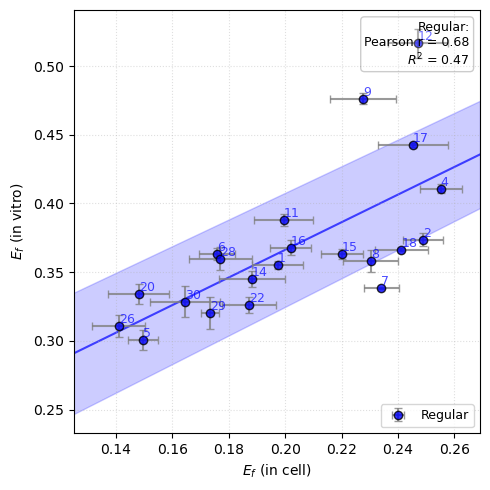

In [12]:
# plot Ef_cell vs Ef_invitro with error bars - BLUE for regular, GREY for GS
mask = construct_stats[['Ef_cell', 'Ef_cell_std', 'Ef_invitro', 'Ef_invitro_std']].notnull().all(axis=1)
plot_df = construct_stats.loc[mask].copy()

regular_df = plot_df[~plot_df['construct'].str.contains('GS', na=False)]

fig, ax = plt.subplots(figsize=(5, 5))

# Plot regular points in blue
if len(regular_df) > 0:
    ax.errorbar(regular_df['Ef_cell'], regular_df['Ef_invitro'], 
                xerr=regular_df['Ef_cell_std'], yerr=regular_df['Ef_invitro_std'],
                fmt='o', color='blue', markeredgecolor='black', markeredgewidth=1,
                ecolor='grey', capsize=3, alpha=0.8, barsabove=False, label='Regular')
    
    # Add labels to regular points
    for idx, row in regular_df.iterrows():
        ax.text(row['Ef_cell'], row['Ef_invitro'], 
                row['construct'], fontsize=9, alpha=0.7, 
                ha='left', va='bottom', color='blue')

# Linear regression for REGULAR constructs
if len(regular_df) > 1:
    x_regular = regular_df['Ef_cell']
    y_regular = regular_df['Ef_invitro']
    
    slope_reg, intercept_reg, r_value_reg, p_value_reg, std_err_reg = sp_stats.linregress(x_regular, y_regular)
    pearson_r_reg, pearson_p_reg = sp_stats.pearsonr(x_regular, y_regular)
    
    x_limits = ax.get_xlim()
    line_x_reg = np.array(x_limits)
    line_y_reg = slope_reg * line_x_reg + intercept_reg
    
    ax.plot(line_x_reg, line_y_reg, color='blue', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)
    
    # Calculate 95% confidence interval for regular
    n_reg = len(x_regular)
    dof_reg = n_reg - 2
    t_val_reg = sp_stats.t.ppf(0.975, dof_reg)
    x_mean_reg = np.mean(x_regular)
    sxx_reg = np.sum((x_regular - x_mean_reg)**2)
    predict_y_reg = slope_reg * x_regular + intercept_reg
    residuals_reg = y_regular - predict_y_reg
    s_resid_reg = np.sqrt(np.sum(residuals_reg**2) / dof_reg)
    se_line_reg = s_resid_reg * np.sqrt(1/n_reg + (line_x_reg - x_mean_reg)**2 / sxx_reg)
    margin_reg = t_val_reg * se_line_reg
    
    ax.fill_between(line_x_reg, line_y_reg - margin_reg, line_y_reg + margin_reg,
                    color='blue', alpha=0.2, zorder=0)

ax.set_xlabel('$E_{f}$ (in cell)')
ax.set_ylabel('$E_{f}$ (in vitro)')
ax.grid(True, linestyle=':', alpha=0.4)

# Add statistics text for regular constructs
if len(regular_df) > 1:
    ax.text(0.975, 0.975, f'Regular:\nPearson r = {pearson_r_reg:.2f}\n$R^2$ = {r_value_reg**2:.2f}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

ax.legend(loc='lower right', frameon=True, fontsize=9)

plt.xlim(x_limits[0], x_limits[1])
plt.tight_layout()
#plt.savefig('Figure_graphs/Fig2/Ef_cell_vs_Ef_invitro_all_blue.svg')